# Reactome Ground Truth Collection
Fetch human pathway → UniProt protein set mappings from the Reactome download files for the protein embedding benchmark.

Same structure as the KEGG ground truth notebook.

In [4]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
from matplotlib.patches import Patch

# 1. Download the UniProt → Reactome pathway mapping

Reactome provides a single TSV file that maps UniProt accessions directly to pathways.  
No ID conversion needed (unlike KEGG where we had to go through Entrez Gene IDs).  

Columns: UniProt ID, Reactome ID, URL, pathway name, evidence code, species

In [5]:
url = "https://reactome.org/download/current/UniProt2Reactome.txt"
cache_path = "database_data/UniProt2Reactome.txt"

import os, time, shutil

os.makedirs("database_data", exist_ok=True)

if not os.path.exists(cache_path):
    print(f"Fetching: {url}")
    tmp_path = cache_path + ".part"
    last_err = None
    for attempt in range(1, 6):
        try:
            with requests.get(url, stream=True, timeout=(30, 120)) as resp:
                resp.raise_for_status()
                with open(tmp_path, "wb") as out:
                    for chunk in resp.iter_content(chunk_size=1 << 20):
                        if chunk:
                            out.write(chunk)
            shutil.move(tmp_path, cache_path)
            last_err = None
            break
        except (requests.exceptions.ChunkedEncodingError,
                requests.exceptions.ConnectionError,
                requests.exceptions.ReadTimeout) as e:
            last_err = e
            print(f"  attempt {attempt} failed: {e!r}; retrying...")
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
            time.sleep(2 ** attempt)
    if last_err is not None:
        raise last_err
else:
    print(f"Using cached file: {cache_path}")

with open(cache_path, encoding="utf-8") as f:
    text = f.read()

print(f"Size: {len(text) / 1e6:.1f} MB")

# Parse into lines
lines = text.strip().split("\n")
print(f"Total lines: {len(lines):,}")
print(f"\nFirst 5 lines:")
for line in lines[:5]:
    print(f"  {line}")


Using cached file: database_data/UniProt2Reactome.txt
Size: 42.7 MB
Total lines: 322,435

First 5 lines:
  A0A023GPK8	R-DME-373753	https://reactome.org/PathwayBrowser/#/R-DME-373753	Nephrin family interactions	IEA	Drosophila melanogaster
  A0A023GRW3	R-DME-72163	https://reactome.org/PathwayBrowser/#/R-DME-72163	mRNA Splicing - Major Pathway	IEA	Drosophila melanogaster
  A0A023GRW3	R-DME-72203	https://reactome.org/PathwayBrowser/#/R-DME-72203	Processing of Capped Intron-Containing Pre-mRNA	IEA	Drosophila melanogaster
  A0A023GRW3	R-DME-9770562	https://reactome.org/PathwayBrowser/#/R-DME-9770562	mRNA Polyadenylation	IEA	Drosophila melanogaster
  A0A023IKK2	R-RNO-202424	https://reactome.org/PathwayBrowser/#/R-RNO-202424	Downstream TCR signaling	IEA	Rattus norvegicus


In [6]:
# Parse into structured data and filter for Homo sapiens
reactome_data = []
for line in lines:
    parts = line.split("\t")
    if len(parts) >= 6:
        uniprot_id = parts[0].strip()
        reactome_id = parts[1].strip()
        pathway_url = parts[2].strip()
        pathway_name = parts[3].strip()
        evidence = parts[4].strip()
        species = parts[5].strip()
        reactome_data.append({
            "uniprot_id": uniprot_id,
            "reactome_id": reactome_id,
            "pathway_name": pathway_name,
            "evidence": evidence,
            "species": species,
        })

df_all = pd.DataFrame(reactome_data)
print(f"Total entries: {len(df_all):,}")
print(f"\nSpecies distribution (top 10):")
print(df_all["species"].value_counts().head(10))
print(f"\nEvidence codes:")
print(df_all["evidence"].value_counts())

Total entries: 322,435

Species distribution (top 10):
species
Homo sapiens               53996
Mus musculus               32487
Rattus norvegicus          31391
Bos taurus                 30271
Sus scrofa                 28874
Canis familiaris           27702
Gallus gallus              22983
Danio rerio                20675
Drosophila melanogaster    17957
Xenopus tropicalis         17646
Name: count, dtype: int64

Evidence codes:
evidence
IEA    277656
TAS     44779
Name: count, dtype: int64


In [7]:
# Filter for Homo sapiens only
df_human = df_all[df_all["species"] == "Homo sapiens"].copy()
print(f"Human entries: {len(df_human):,}")
print(f"Unique UniProt IDs: {df_human['uniprot_id'].nunique():,}")
print(f"Unique Reactome pathways: {df_human['reactome_id'].nunique():,}")
print(f"\nSample entries:")
df_human.head(10)

Human entries: 53,996
Unique UniProt IDs: 12,136
Unique Reactome pathways: 2,331

Sample entries:


,uniprot_id,reactome_id,pathway_name,evidence,species
1102,A0A075B6P5,R-HSA-166663,Initial triggering of complement,TAS,Homo sapiens
1103,A0A075B6P5,R-HSA-173623,Classical antibody-mediated complement activation,TAS,Homo sapiens
1104,A0A075B6P5,R-HSA-198933,Immunoregulatory interactions between a Lympho...,TAS,Homo sapiens
1105,A0A075B6P5,R-HSA-202733,Cell surface interactions at the vascular wall,TAS,Homo sapiens
1106,A0A075B6P5,R-HSA-2029481,FCGR activation,IEA,Homo sapiens
1107,A0A075B6P5,R-HSA-2029481,FCGR activation,TAS,Homo sapiens
1108,A0A075B6P5,R-HSA-2029482,Regulation of actin dynamics for phagocytic cu...,TAS,Homo sapiens
1109,A0A075B6P5,R-HSA-2029485,Role of phospholipids in phagocytosis,TAS,Homo sapiens
1110,A0A075B6P5,R-HSA-2168880,Scavenging of heme from plasma,TAS,Homo sapiens
1111,A0A075B6P5,R-HSA-2454202,Fc epsilon receptor (FCERI) signaling,TAS,Homo sapiens


# 2. Build pathway → protein set and protein → pathway set

In [8]:
# pathway → set of UniProt IDs
pathway_to_proteins = defaultdict(set)
for _, row in df_human.iterrows():
    pathway_to_proteins[row["reactome_id"]].add(row["uniprot_id"])
pathway_to_proteins = dict(pathway_to_proteins)

# protein → set of pathway IDs (for matrix construction)
protein_to_pw_set = defaultdict(set)
for _, row in df_human.iterrows():
    protein_to_pw_set[row["uniprot_id"]].add(row["reactome_id"])
protein_to_pw_set = dict(protein_to_pw_set)

# pathway names lookup
pathway_names = {}
for _, row in df_human.iterrows():
    pathway_names[row["reactome_id"]] = row["pathway_name"]

print(f"Pathways: {len(pathway_to_proteins):,}")
print(f"Proteins: {len(protein_to_pw_set):,}")

# Pathway size distribution
sizes = sorted([len(p) for p in pathway_to_proteins.values()])
print(f"\nPathway size distribution:")
print(f"  Min: {sizes[0]}, Median: {sizes[len(sizes)//2]}, Mean: {np.mean(sizes):.1f}, Max: {sizes[-1]}")

# Pathways per protein
pw_per_prot = sorted([len(v) for v in protein_to_pw_set.values()])
print(f"\nPathways per protein:")
print(f"  Min: {pw_per_prot[0]}, Median: {pw_per_prot[len(pw_per_prot)//2]}, Mean: {np.mean(pw_per_prot):.1f}, Max: {pw_per_prot[-1]}")

Pathways: 2,331
Proteins: 12,136

Pathway size distribution:
  Min: 1, Median: 11, Mean: 21.3, Max: 478

Pathways per protein:
  Min: 1, Median: 2, Mean: 4.1, Max: 219


In [9]:
# 5 largest and smallest pathways
print("5 largest pathways:")
for pid, prots in sorted(pathway_to_proteins.items(), key=lambda x: len(x[1]), reverse=True)[:5]:
    print(f"  {pid} {pathway_names[pid]}: {len(prots)} proteins")

print(f"\n5 smallest pathways:")
for pid, prots in sorted(pathway_to_proteins.items(), key=lambda x: len(x[1]))[:5]:
    print(f"  {pid} {pathway_names[pid]}: {len(prots)} proteins")

5 largest pathways:
  R-HSA-6798695 Neutrophil degranulation: 478 proteins
  R-HSA-9752946 Expression and translocation of olfactory receptors: 413 proteins
  R-HSA-212436 Generic Transcription Pathway: 357 proteins
  R-HSA-983168 Antigen processing: Ubiquitination & Proteasome degradation: 296 proteins
  R-HSA-418594 G alpha (i) signalling events: 260 proteins

5 smallest pathways:
  R-HSA-5619061 Defective SLC33A1 causes spastic paraplegia 42 (SPG42): 1 proteins
  R-HSA-9637698 Phagocyte cell death caused by cytosolic Mtb: 1 proteins
  R-HSA-5578998 Defective OPLAH causes OPLAHD: 1 proteins
  R-HSA-4043911 Defective PMM2 causes PMM2-CDG: 1 proteins
  R-HSA-5602410 TLR3 deficiency - HSE: 1 proteins


# 3. Evaluate label thresholds

Same analysis as KEGG: how does the positive/negative balance shift with different shared pathway thresholds?

Note: Reactome has many more pathways than KEGG (and more hierarchical — sub-pathways nest inside parent pathways), so we might see different distributions.

In [10]:
# Compute shared pathway counts using the dot product approach
reactome_protein_list = sorted(protein_to_pw_set.keys())
all_pathways_sorted = sorted(set().union(*protein_to_pw_set.values()))
pw_to_idx = {pw: i for i, pw in enumerate(all_pathways_sorted)}

n_react = len(reactome_protein_list)
print(f"Reactome proteins: {n_react}")
print(f"Reactome pathways: {len(all_pathways_sorted)}")
print(f"Unique pairs: {n_react * (n_react - 1) // 2:,}")

# Binary membership matrix
membership = np.zeros((n_react, len(all_pathways_sorted)), dtype=np.float32)
for i, prot in enumerate(reactome_protein_list):
    for pw in protein_to_pw_set[prot]:
        membership[i, pw_to_idx[pw]] = 1.0

print(f"Membership matrix: {membership.shape}")
print(f"Computing shared pathway counts...")
shared_counts = membership @ membership.T
print("Done!")

Reactome proteins: 12136
Reactome pathways: 2331
Unique pairs: 73,635,180
Membership matrix: (12136, 2331)
Computing shared pathway counts...
Done!


In [11]:
# Shared pathway count distribution
upper_tri = shared_counts[np.triu_indices(n_react, k=1)]
total_pairs = len(upper_tri)

print(f"Total evaluable pairs (both in Reactome): {total_pairs:,}")
print(f"Pairs sharing 0 pathways: {np.sum(upper_tri == 0):,}")
print(f"\nShared pathway count distribution (first 20):")
for i in range(min(20, int(upper_tri.max()) + 1)):
    count = np.sum(upper_tri == i)
    if count > 0:
        print(f"  {i:>3} shared pathways: {count:>12,} pairs ({count/total_pairs*100:.2f}%)")

print(f"\n  Max shared pathways: {int(upper_tri.max())}")

Total evaluable pairs (both in Reactome): 73,635,180
Pairs sharing 0 pathways: 72,544,841

Shared pathway count distribution (first 20):
    0 shared pathways:   72,544,841 pairs (98.52%)
    1 shared pathways:      893,227 pairs (1.21%)
    2 shared pathways:      111,826 pairs (0.15%)
    3 shared pathways:       29,527 pairs (0.04%)
    4 shared pathways:       16,717 pairs (0.02%)
    5 shared pathways:        7,626 pairs (0.01%)
    6 shared pathways:        8,649 pairs (0.01%)
    7 shared pathways:        5,260 pairs (0.01%)
    8 shared pathways:        2,952 pairs (0.00%)
    9 shared pathways:        1,135 pairs (0.00%)
   10 shared pathways:          669 pairs (0.00%)
   11 shared pathways:          955 pairs (0.00%)
   12 shared pathways:          465 pairs (0.00%)
   13 shared pathways:          316 pairs (0.00%)
   14 shared pathways:          366 pairs (0.00%)
   15 shared pathways:        1,983 pairs (0.00%)
   16 shared pathways:        3,206 pairs (0.00%)
   17 shared

In [12]:
# Label distribution for different thresholds
thresholds = [1, 2, 3, 4]

n_total = 20_431  # our human proteome size
total_possible_pairs = n_total * (n_total - 1) // 2
both_in_reactome = n_react * (n_react - 1) // 2
nan_pairs = total_possible_pairs - both_in_reactome

results = {}
for threshold in thresholds:
    n_positive = int(np.sum(upper_tri >= threshold))
    n_negative = int(both_in_reactome - n_positive)
    results[threshold] = {"positive": n_positive, "negative": n_negative, "nan": nan_pairs}

print(f"{'Threshold':<15} {'Positive':>12} {'Negative':>12} {'NaN':>12} {'Pos/Neg ratio':>14}")
print("-" * 70)
for t, r in results.items():
    ratio = r['positive'] / r['negative'] if r['negative'] > 0 else float('inf')
    print(f"≥ {t} pathway{'s' if t > 1 else ' ':<10} {r['positive']:>12,} {r['negative']:>12,} {r['nan']:>12,} {ratio:>14.6f}")

Threshold           Positive     Negative          NaN  Pos/Neg ratio
----------------------------------------------------------------------
≥ 1 pathway              1,090,339   72,544,841  135,067,485       0.015030
≥ 2 pathways               197,112   73,438,068  135,067,485       0.002684
≥ 3 pathways                85,286   73,549,894  135,067,485       0.001160
≥ 4 pathways                55,759   73,579,421  135,067,485       0.000758


# 4. Build the ground truth matrix

- `1` = positive (share ≥ 1 pathway, both in Reactome)
- `0` = negative (share 0 pathways, both in Reactome)
- `NaN` = at least one protein not in any Reactome pathway

Proteins ordered alphabetically — same order as the KEGG matrix.

## 4.1 Load the protein accessions of all proteins in the human proteome

In [13]:
from Bio import SeqIO

fasta_path = '/home/sander/apps/prot_GPT/fasta/human_proteome_canonical_31032022.fasta'

protein_sequences = {}
for record in SeqIO.parse(fasta_path, 'fasta'):
    protein_id = record.id.split('|')[1]
    sequence = str(record.seq)
    protein_sequences[protein_id] = sequence

all_proteins = list(protein_sequences.keys())
all_proteins_sorted = sorted(all_proteins)
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}

print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")

Total proteins: 20372
Matrix shape: 20372 x 20372


## 4.2 Build the matrix

In [14]:
# Initialize all NaN
reactome_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Get indices of proteins that are in Reactome AND in our FASTA
reactome_in_fasta = [p for p in protein_to_pw_set.keys() if p in prot_to_idx]
reactome_indices = np.array([prot_to_idx[p] for p in reactome_in_fasta])

print(f"Reactome proteins in our vocabulary: {len(reactome_indices)} / {n}")
print(f"Reactome proteins NOT in FASTA: {len(protein_to_pw_set) - len(reactome_indices)}")

# Set all Reactome×Reactome pairs to 0 (negative by default)
reactome_matrix[np.ix_(reactome_indices, reactome_indices)] = 0.0
print("Set all Reactome×Reactome pairs to 0 (negative)")

Reactome proteins in our vocabulary: 11328 / 20372
Reactome proteins NOT in FASTA: 808
Set all Reactome×Reactome pairs to 0 (negative)


In [15]:
# Set positives: pairs sharing ≥ 1 pathway
# Filter membership to only proteins in our vocabulary
reactome_protein_list_fasta = sorted([p for p in protein_to_pw_set.keys() if p in prot_to_idx])

membership_fasta = np.zeros((len(reactome_protein_list_fasta), len(all_pathways_sorted)), dtype=np.float32)
for i, prot in enumerate(reactome_protein_list_fasta):
    for pw in protein_to_pw_set[prot]:
        membership_fasta[i, pw_to_idx[pw]] = 1.0

shared = membership_fasta @ membership_fasta.T

# Map to full matrix indices
full_indices = np.array([prot_to_idx[p] for p in reactome_protein_list_fasta])

# Set positives where shared ≥ 1 (exclude diagonal)
pos_i, pos_j = np.where(shared >= 1)
mask = pos_i != pos_j
pos_i, pos_j = pos_i[mask], pos_j[mask]

reactome_matrix[full_indices[pos_i], full_indices[pos_j]] = 1.0
print(f"Set {len(pos_i):,} positive entries (both directions)")

Set 2,009,594 positive entries (both directions)


In [16]:
# Set diagonal to NaN
np.fill_diagonal(reactome_matrix, np.nan)

# Verify counts (upper triangle only)
upper = reactome_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(reactome_matrix, reactome_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):    1,004,797
  Negative (0):   63,151,331
  NaN:           143,342,878
  Total:         207,499,006

  Pos/Neg ratio: 0.015911
  Matrix is symmetric: True


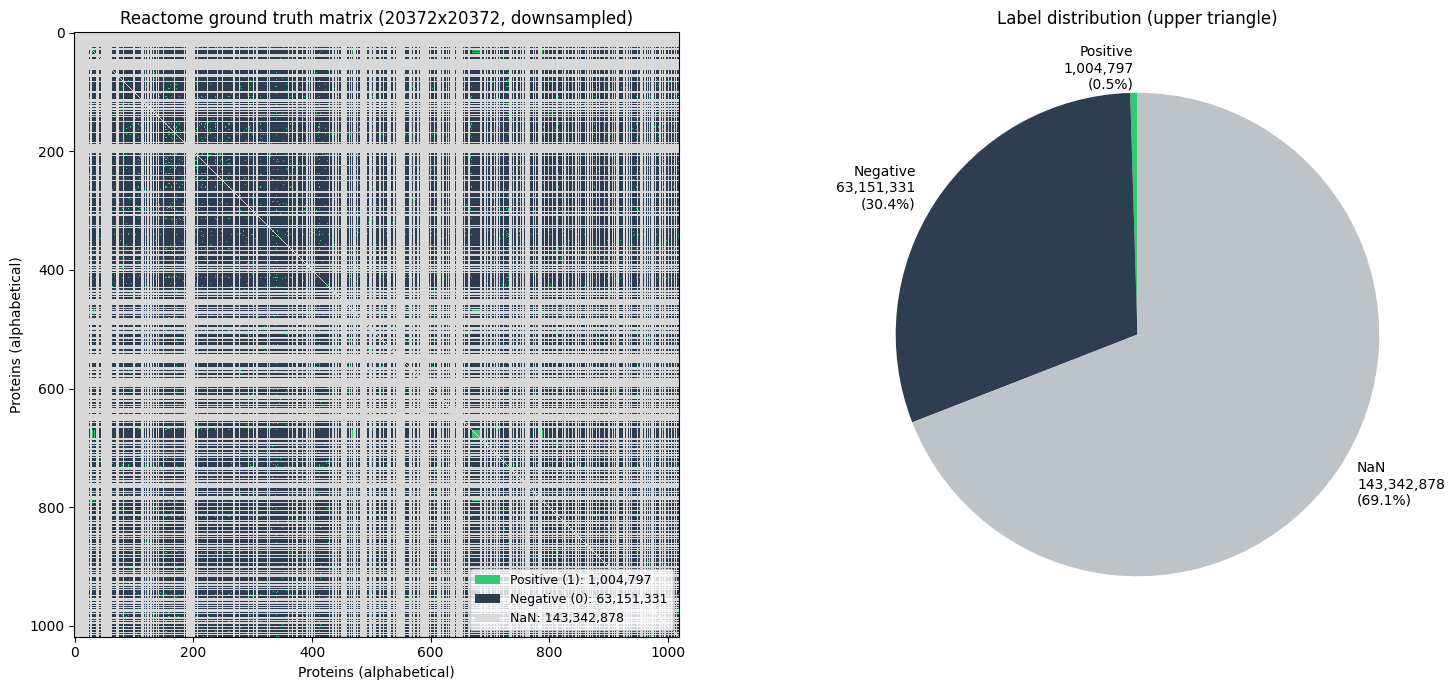

In [17]:
# Visualize the matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: full matrix (downsampled for visualization)
step = max(1, n // 1000)
display_matrix = reactome_matrix[::step, ::step]

rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

rgb[nan_mask] = [0.85, 0.85, 0.85]  # NaN = light grey
rgb[neg_mask] = [0.17, 0.24, 0.31]  # Negative = dark blue
rgb[pos_mask] = [0.18, 0.80, 0.44]  # Positive = green

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"Reactome ground truth matrix ({n}x{n}, downsampled)", fontsize=12)
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# Right: pie chart
sizes = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# save
import os

# Save matrix as .npz
save_ppi_ground_truth(Path(GT_DIR_DEFAULT) / "reactome_ground_truth_matrix.npz", reactome_matrix)

# Save protein order as plain text (same order as KEGG — alphabetical)
with open("reactome_ground_truth_proteins.tsv", "w") as f:
    f.write("idx\tprotein\n")
    for i, p in enumerate(all_proteins_sorted):
        f.write(f"{i}\t{p}\n")

npz_size = os.path.getsize("reactome_ground_truth_matrix.npz") / 1e6
print(f"Saved reactome_ground_truth_matrix.npz ({npz_size:.1f} MB)")
print(f"Saved reactome_ground_truth_proteins.tsv")
print(f"\nTo load later:")
print(f"  matrix = np.load('reactome_ground_truth_matrix.npz')['matrix']")
print(f"  # shape ({n}, {n}), values: 0, 1, NaN")

Saved reactome_ground_truth_matrix.npz (56.0 MB)
Saved reactome_ground_truth_proteins.tsv

To load later:
  matrix = np.load('reactome_ground_truth_matrix.npz')['matrix']
  # shape (20372, 20372), values: 0, 1, NaN


# Quick check of known positive labels

In [20]:
proteins_to_check = ["NAT10", "NOP56", "SNU13", "NOP58"]

# Map gene names to UniProt IDs using our FASTA headers
from Bio import SeqIO

gene_to_uniprot = {}
fasta_path = '/home/sander/apps/prot_GPT/fasta/human_proteome_canonical_31032022.fasta'
for record in SeqIO.parse(fasta_path, 'fasta'):
    # Extract gene name from FASTA header: e.g. "GN=NAT10"
    desc = record.description
    if 'GN=' in desc:
        gn = desc.split('GN=')[1].split()[0]
        uid = record.id.split('|')[1]
        if gn in proteins_to_check:
            gene_to_uniprot.setdefault(gn, []).append(uid)

print("Gene → UniProt mapping:")
for gn in proteins_to_check:
    print(f"  {gn}: {gene_to_uniprot.get(gn, ['NOT FOUND'])}")

# Use first match for each
uid_map = {gn: gene_to_uniprot[gn][0] for gn in proteins_to_check}

# Check all 12 ordered pairs (or 6 unique pairs, shown both ways)
from itertools import combinations
print(f"\nPairwise Reactome ground truth labels:")
print(f"{'Protein A':<10} {'Protein B':<10} {'UniProt A':<12} {'UniProt B':<12} {'Label':>8}  Shared pathways")
print("-" * 85)
for a, b in combinations(proteins_to_check, 2):
    uid_a, uid_b = uid_map[a], uid_map[b]
    idx_a, idx_b = prot_to_idx[uid_a], prot_to_idx[uid_b]
    label = reactome_matrix[idx_a, idx_b]
    
    # Count shared pathways
    pw_a = protein_to_pw_set.get(uid_a, set())
    pw_b = protein_to_pw_set.get(uid_b, set())
    shared_pw = pw_a & pw_b
    
    label_str = "NaN" if np.isnan(label) else int(label)
    print(f"{a:<10} {b:<10} {uid_a:<12} {uid_b:<12} {label_str:>8}  {len(shared_pw)} shared: {', '.join(sorted(shared_pw)) if shared_pw else '-'}")

print(f"\nTotal pairs checked: {len(list(combinations(proteins_to_check, 2)))}")
print(f"(× 2 for both directions = 12 entries in symmetric matrix)")

Gene → UniProt mapping:
  NAT10: ['Q9H0A0']
  NOP56: ['O00567']
  SNU13: ['P55769']
  NOP58: ['Q9Y2X3']

Pairwise Reactome ground truth labels:
Protein A  Protein B  UniProt A    UniProt B       Label  Shared pathways
-------------------------------------------------------------------------------------
NAT10      NOP56      Q9H0A0       O00567              1  1 shared: R-HSA-6790901
NAT10      SNU13      Q9H0A0       P55769              1  1 shared: R-HSA-6790901
NAT10      NOP58      Q9H0A0       Q9Y2X3              1  1 shared: R-HSA-6790901
NOP56      SNU13      O00567       P55769              1  2 shared: R-HSA-6790901, R-HSA-6791226
NOP56      NOP58      O00567       Q9Y2X3              1  2 shared: R-HSA-6790901, R-HSA-6791226
SNU13      NOP58      P55769       Q9Y2X3              1  2 shared: R-HSA-6790901, R-HSA-6791226

Total pairs checked: 6
(× 2 for both directions = 12 entries in symmetric matrix)


this checks out!